---
title: "$\\Sigma-\\Delta$-modulator phase noise in fractional-N PLL's"
author: "Juan F. Osorio"
date: "2014-06-09"
description: "This is a notebook explaining the fundamentals of Sigma-Delta modulators as used in fractional-N PLLs. It compares the theoretical analysis with a implementation developed in Python."
categories: [Theoretical analysis, Fundamentals, PLLS, Sigma-Delta, Fractional-N]
---

# $\Sigma-\Delta$-modulator phase noise in fractional-N PLL's

## Library imports

In [1]:
# Array fast operation
import numpy as np
from numpy import (ones, pi, log10)

# Signal processing routines
import scipy.signal as sig

# Plotting 
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.figsize']  = (9,6)
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.labelsize'] = 'large'

# Add the path to the plldesigner module
import sys
sys.path.append('../../..')
# Print local directory



# Load modules for plldesign https://github.com/jfosorio/plldesigner
import plldesigner.pnoise as pn
import plldesigner.sdmod as sdmod

%matplotlib inline

## Introduction

The first time that I had to design a fractional-N PLL, it took me quite a while to gain confidence over the model I was using to predict the phase noise generated by the $\Sigma\Delta$-modulators(SDM).  A handfull of of mathematical pitfalls make the subject tricky at first, and I often wished for reference code that would make the task much easier. This is one of those topics for which a notebook combining theory and code feels particular appealing.

This entry is organized as follow: the first section revisits SDM theory; the second section explains how a mash SDM works and presents a Python model; and the final section shows the results of the model and compares them with the theoretical prediction.  The SDM model forms part of a broader PLL-design package available in github.

## Linear phase noise analysis for the excess of phase noise at the output of a fractional divider using a $\Sigma-\Delta$ modulator

The circuit in **Figure 1** implements fractional division of the input frequency $f_{in}$  by the ratio $N+f(z)$ using a SDM. Because bulding a circuit that divides directly by a non-integer factor is difficult, we employ an integer divider whose **average** division ratio equals the desired fractional value. This time-varying divition introduces unwanted phase changes in the output and we are therefore interested in the **power spectral density** of these disturbances.

![Fractional Divider](images/fractional_divider.png){fig-alt="Fractional Divider" height=400px fig-align="center"}
<!-- <br>
<img src="images/fractional_divider.png" alt="Fractional divider" height=400px/>
<center> Figure 1. Topology of a fractional divider made with a SDM </center>
<br> -->


The instantaneous frequency division of the divider in the figure is given by:


$$\begin{equation}
    N_{div}(z) = N+f(z)+H_{s}(z) \Delta_{q}(z),
\end{equation}$$

Where **$N$ is that integer part** of the division ratio, $f(z)$ is the fractional part, and 
$H_s(z) \Delta_{q}(z)$ is the instantaneous error produced by an SDM of order m. The noise of the SDM has two components: $\Delta_{q}(z)$, the quantization noise, and $H_s(z)$, the noise-shaping transfer function of the modulator.  

The output frequency of the SD modulator is 

$$\begin{equation}
    f_{div}(z) = \frac{f_{in}}{N+f(z)+H_s(z) \Delta_{q}(z)},
\end{equation}$$

which,using the approximation $\frac{1}{1+x} \approx  1-x \: \text{for } x << 1$, becomes

$$\begin{equation}
    f_{div}(z) = \frac{f_{in}}{N+f(z)}\left(1 - \frac{H_s(z) \Delta_{q}(z)}{N+f(z)}\right),
\end{equation}$$

Because $\frac{f_{in}}{N+f(z)}$ equals, under lock condition, the PLL reference frequency $f_{ref}$, the instantaneous frequency error as a function of the target frequency equals:

$$\begin{equation}
    \Delta_{f_{div}}(z) = - f_{ref} \frac{ H_s(z) \Delta_{q}(z)}{N+f(z)}.
\end{equation}$$

The power spectral density of the quantization noise can be approximated in the same way than the quantization noise of a ADC: for a minimum step size $\delta$, the error variance is 

$$\begin{equation}
    \Delta_{q}^2 = \frac{1}{12} (step^2),
\end{equation}$$

and assuming this noise is uniformly distributed over the Nyquist bandwidth $f_{ref}/2$, its power spectral density is

$$\begin{equation}
    \Delta_{q}^2 = \frac{1}{6 f_{ref}} (step^2/Hz). 
\end{equation}$$

Then we consider the transfer function of the SDM that for Mash-1-1-1 SDM is given by[1]

$$\begin{equation}
    H_s(z)= (1-z^{-1})^m, 
\end{equation}$$

where m is the SDM order. 

Putting this pieces together gives

$$\begin{equation}
    \Delta_{f_{div}}(z)^2 =  \left|f_{ref} \frac{ (1-z^{-1})^m}{N+f(z)}\right|^2 \frac{1}{6 f_{ref}}.
\end{equation}$$

Because we are interesting in the phase, we integrate this expression in the z-domain: 

$$\begin{equation}
\Phi_{div}(z) = \frac{2 \pi T_{ref} \Delta_{f_{div}}(z)}{1-z^{-1}},
\end{equation}$$

so that
    
$$\begin{equation}
\Phi_{div}(z)^2 = \frac{(2 \pi)^2}{6 f_{ref}} \frac{|1-z^{-1}|^{2(m-1)}}{(N+f(z))^2}(Rad^2/Hz).
\end{equation}$$


By definition $\mathcal{L}(z)= \Phi_{div}(z)^2/2$, hence

$$\begin{equation}
	\mathcal{L}(z) = \frac{(2 \pi)^2}{12 f_{ref}} \frac{|1-z^{-1}|^{2(m-1)}}{(N+f(z))^2}(Rad^2/Hz),
\end{equation}$$

which can be rewritten by substituting $z$ by $e^{sT_{ref}}$. Denoting the frequency offset $f_m$ yields

$$\begin{equation}
  \mathcal{L}(f_m) = \frac{(2 \pi)^2}{12 f_{ref}} \frac{[2 sin(\pi f_m/ f_{ref})]^{2(m-1)}}{(N+f(z))^2}.
\end{equation}$$

The expression above gives the noise at the **output of the divider**. Earlier references such us [1] and [2] report the noise **at the divider input**; the two forms differ only by the factor $(N+f(z))^2$ that is the expected transfer function of the fractional divider.

## Using the pnoise module and the sdmod to simulate a SDM

Within the [plldesigner](https://github.com/jfosorio/plldesigner) project two modules provide classes for creating SDM sequences and performing calculation with phase noise signals.

The sigma delta modulator is realized by an accumulator that adds the input word on every step and wrap around when it reaches MAX. Here MAX is the larges value of the SDM register can hold, namelly $2^N-1$ for an N-bit register. The snippet below shows how a first-order modulator is implemented:

```python
k = round(Nfloat*2**N)
for j in arange(0, L):
    state = state + k[j - 1]
    if state > _maxvalue:
        over = 1
        state -= _maxvalue + 1
    else:
        over = 0
        sd[j] = over
```

The implementation of first, second and third order Sigma-delta modulators can be found in: [plldesigner](https://github.com/jfosorio/plldesigner).

### Creating a SDM sequence with the sdmod module

the gen_mash function of the sdmod renerates the output sequence of a 1-1-1 Mash $\Sigma\Delta$. Its inputs are the modulator order , the accumulator word length and the
input vector $k[n]$. The snippet below shows how to produce the sequence.

Mean value of the sequence: 0.253220



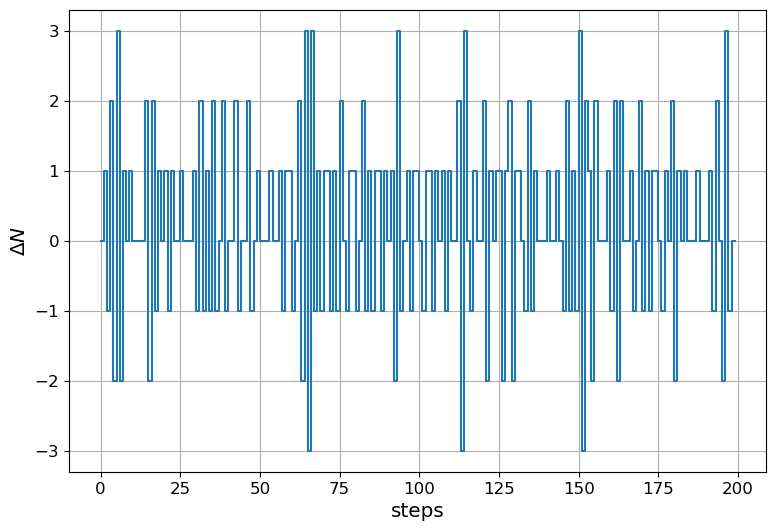

In [2]:
# Parameters 
NsdBits = 19
fref = 27.6e6
Tref = 1.0/fref

# Create a SDM sequency 
fracnum = ((0.253232*2**NsdBits)*ones(100000)).astype(int)
sd, per = sdmod.gen_mash(3,NsdBits,fracnum)
fig, ax = plt.subplots()
ax.step(np.r_[0:200],sd[:200]);
ax.set_xlabel('steps') #x label
ax.set_ylabel('$\\Delta N$') #y label
print("Mean value of the sequence: {:2.6f}\n".format(sd.mean()))
plt.show()

The phase error $\phi_{out}[n]$ can be calculated integrating the error in the frequency. Then the power spectrum density is estimated with the [welch periodogram](http://docs.scipy.org/doc/scipy-dev/reference/generated/scipy.signal.welch.html) and compared with the theoretical prediction.


Integrated phase noise
Theory: 4.443 (rad,rms)
Sim   : 4.427 (rad,rms)


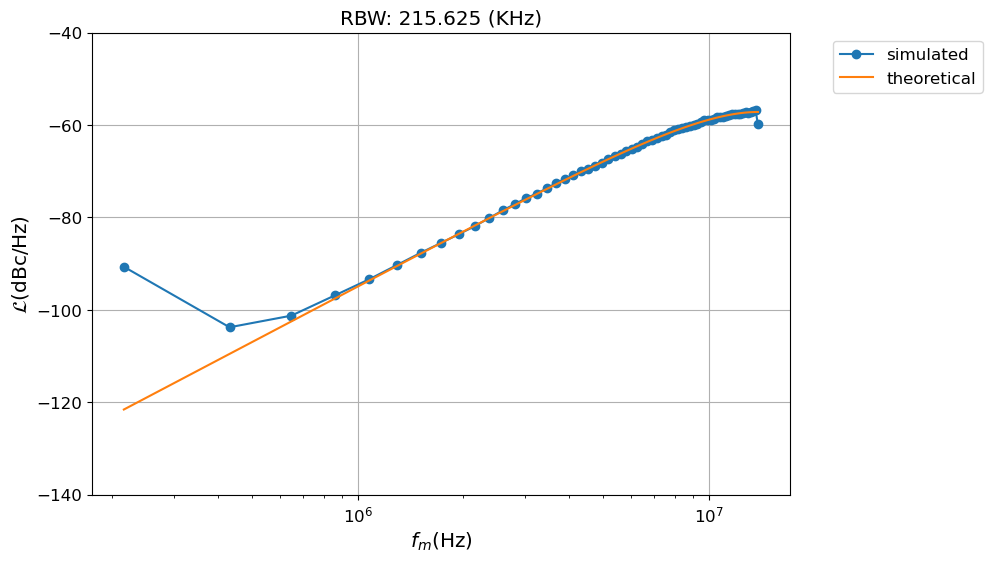

In [3]:
# Phi_er at the output equals \sum{\DeltaN*fref}*Tref
phi_div = 2*pi*(sd-fracnum[0]/2**NsdBits).cumsum()

# Calculate the spectrum
npoints = 2**7
f, Phi2_div = sig.welch(phi_div, fref, window='blackman', nperseg=npoints)
rbw = fref/2/(len(f)-1)
ind = (f>1e5) & (f<1e9)
sim = pn.Pnoise(f[ind],10*log10(Phi2_div[ind]/2), label='simulated')

# calcualte the L teorical
theory = sdmod.L_mash_dB(3,fref)
theory.fm = f[ind]
theory.label = 'theoretical'

# Calculate the integral value of the two
print('''
Integrated phase noise
======================
Theory: {:2.3f} (rad,rms)
Sim   : {:2.3f} (rad,rms)'''.format(theory.integrate(),sim.integrate()))

# plot both specgturms
fig, ax = plt.subplots()
sim.plot('o-', ax=ax)
ax = theory.plot(ax=ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
ax.set_title('RBW: {:2.3f} (KHz)'.format(rbw/1e3))
val = ax.set_ylim([-140,-40])
plt.show()

## Non-linear behavior of the $\Sigma-\Delta$ modulator

The previous theory fails to predict spurs that can occur when the input is a rational number.  This is demonstrated using the same SDM but with a input equivalent to 1/8. It is important to understand these spurs as they can fall in band after they are folded back by the non-linearity of the CP and the PFD.

Mean value of the sequence: 0.24999



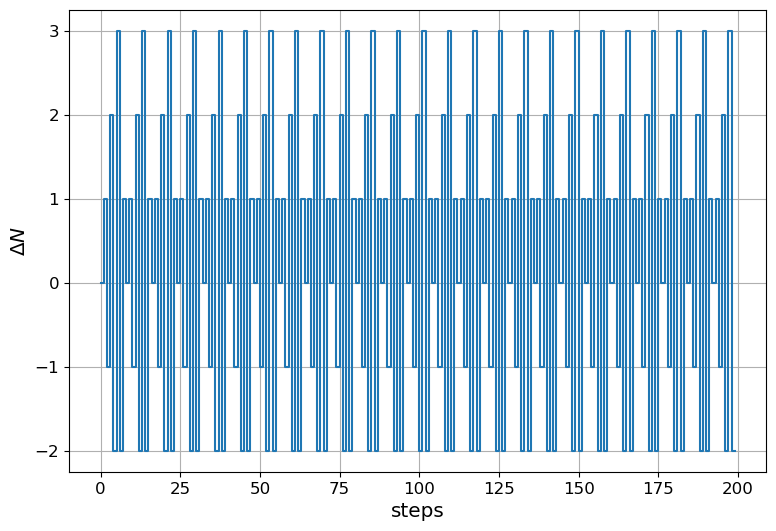

In [4]:
# Fraction number
fracnum = (2/8*2**NsdBits)*ones(100000)

# Produce the SDM sequence
sd, per = sdmod.gen_mash(3,NsdBits,fracnum)

# Calculate the phase error and its PSD
phi_div = 2*pi*(sd-fracnum[0]/2**NsdBits).cumsum()
f, Phi2_div = sig.welch(phi_div, fref, window="blackman", nperseg=npoints)
sim = pn.Pnoise(f[ind],10*log10(Phi2_div[ind]/2), label='simulated')

# Create a figure and axis using plt.subplots
fig, ax = plt.subplots()
ax.step(np.r_[0:200], sd[:200])
ax.set_xlabel('steps')  # x label
ax.set_ylabel('$\\Delta N$')  # y label

print("Mean value of the sequence: {:2.5f}\n".format(sd.mean()))
plt.show()

In [5]:
sd, per = sdmod.gen_mash(3,NsdBits,fracnum)

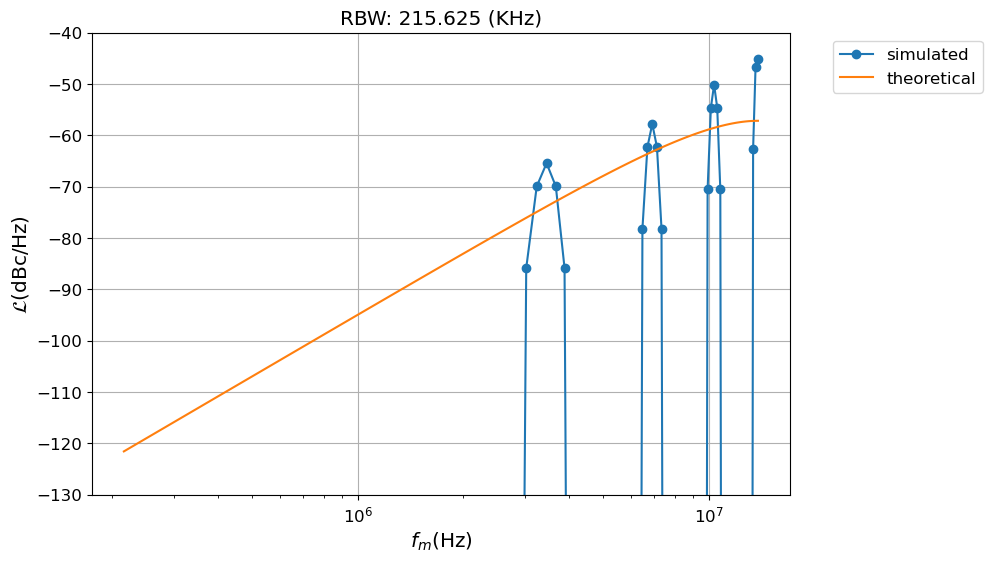

In [6]:
#Plot the power spectrum density
fig, ax = plt.subplots()
sim.plot('o-', ax=ax)
theory.plot(ax=ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
ax.set_title('RBW: {:2.3f} (KHz)'.format(rbw/1e3))
ax.set_ylim([-130,-40])
ax.grid(True)
plt.show()

The spurs appearance and amplitude depend both of the input word and the initial state of the registers of the modulator [3]. It can be that initializing the first register of the first register of the SDM creates enough dithering to reduce the spurs The gen_mash accepts a fourth argument to initialize the mash registers. This argument is a tuple with a number of elements that equals the order of the SDM.

Mean value of the sequence: 0.24999



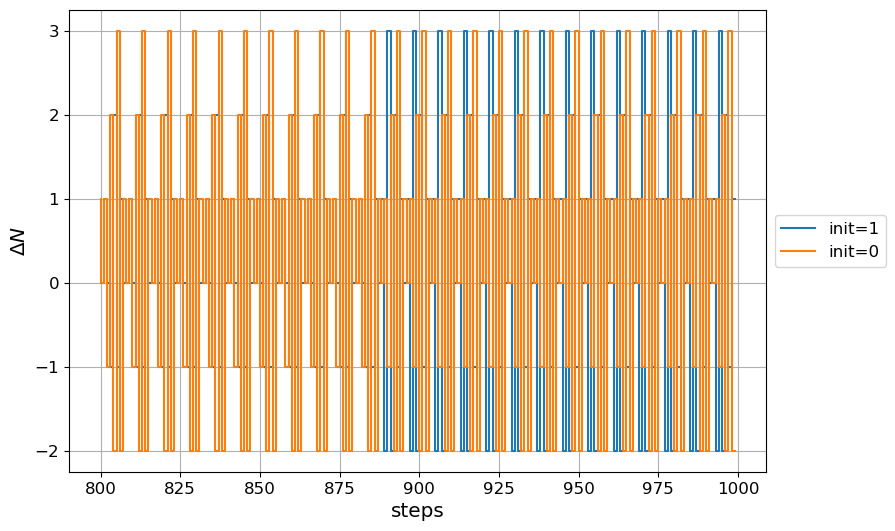

In [7]:
sd_init, per = sdmod.gen_mash(3,NsdBits,fracnum,(1,0,0))

# Calculate the phase error and its PSD
phi_div = 2*pi*(sd_init-fracnum[0]/2**NsdBits).cumsum()
f, Phi2_div = sig.welch(phi_div, fref, window="blackman", nperseg=npoints)
sim = pn.Pnoise(f[ind],10*log10(Phi2_div[ind]/2), label='simulated')

# plot the sequence
pltpoints = np.r_[800:1000]

fig, ax = plt.subplots()

ax.step(pltpoints,sd_init[pltpoints],label='init=1')
ax.step(pltpoints,sd[pltpoints], label='init=0')
ax.set_xlabel('steps') #x label
ax.set_ylabel('$\\Delta N$') #y label
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
print("Mean value of the sequence: {:2.5f}\n".format(sd.mean()))
plt.show()

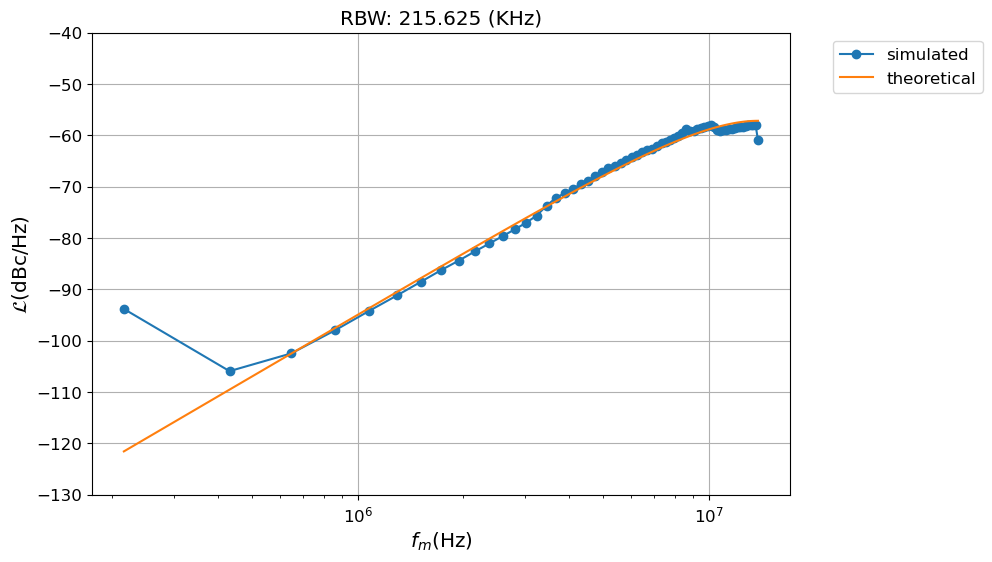

In [8]:
#Plot the power spectrum density

fig, ax = plt.subplots()
sim.plot('o-', ax=ax)
theory.plot(ax=ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
ax.set_title('RBW: {:2.3f} (KHz)'.format(rbw/1e3))
ax.set_ylim([-130,-40])
plt.show()

THe effect of initializing the registers is to smoth the power spectrum density of the output, long enough observation would made the spurs apperent again.

## Conclusion

This entry revisits $\Sigma\Delta$-modulator theory using  Python. It explains and documents the key features of SDM modulators using as a example a MASH implementation. Thanks to the Jupyter Notebook enviroment teh results are easy to reproduce. 

## References



1. B. Miller and R. J. Conley, “A multiple modulator fractional divider,” IEEE Transactions on Instrumentation and Measurement, vol. 40, no. 3, pp. 578–583, 1991.

2. T. A. D. Riley, M. A. Copeland, and T. A. Kwasniewski, “Delta-sigma modulation in fractional-N frequency synthesis,” IEEE Journal of Solid-State Circuits, vol. 28, no. 5, pp. 553–559, May 1993.

3. Kozak, M., Kale, I., "Rigorous analysis of delta-sigma modulators for fractional-N PLL frequency synthesis," IEEE Transactions on Circuits and Systems I: Regular Papers 51, 1148–1162, 2004. (doi:10.1109/TCSI.2004.829308)